<a href="https://colab.research.google.com/github/yoloaryan/Predicting_emotions_of_text/blob/main/Predictiong_emotions_of_text.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Emotion Classification with RNNs, LSTM's & GRUs**

Classifying text into 6 emotions(sadness,joy,love,anger,fear, surprise )by comparing plain recurrent models before nuilding an Advancement Bidirectional GRU

# 1.Import Libraries


In [81]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Bidirectional,
    Dense,
    Dropout
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# 2. Load Dataset

In [48]:
emotion_dataset = load_dataset('dair-ai/emotion')

emotion_dataset['train']['text']

Column(['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy'])

In [49]:
emotion_dataset['train']['text']
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']
train_label

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']


In [50]:
label_names =emotion_dataset['train'].features['label'].names

In [51]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [52]:
#mapping o fthe data , assigning the values to the  assigned emotions in the form such as   0 -> sadness for refrencde
for i in train_label:
  print(label_names[i]) # label_names[3]]

Streaming output truncated to the last 5000 lines.
sadness
sadness
anger
fear
love
joy
anger
sadness
sadness
joy
fear
joy
fear
love
love
anger
anger
sadness
fear
sadness
sadness
surprise
love
joy
joy
love
sadness
joy
joy
fear
sadness
anger
anger
sadness
love
fear
fear
anger
anger
joy
sadness
sadness
joy
joy
fear
sadness
joy
love
fear
anger
sadness
joy
anger
surprise
fear
joy
joy
love
fear
sadness
joy
anger
fear
anger
sadness
sadness
sadness
anger
sadness
fear
joy
anger
anger
sadness
fear
joy
anger
fear
sadness
joy
fear
joy
love
anger
fear
fear
fear
fear
joy
anger
anger
sadness
joy
sadness
joy
sadness
sadness
joy
sadness
fear
fear
joy
sadness
joy
sadness
joy
fear
anger
sadness
joy
anger
joy
joy
sadness
joy
joy
anger
anger
joy
joy
joy
sadness
joy
joy
joy
anger
anger
joy
love
joy
love
joy
joy
joy
sadness
joy
sadness
surprise
sadness
anger
anger
anger
fear
fear
joy
fear
fear
joy
anger
joy
joy
joy
love
joy
fear
sadness
sadness
surprise
sadness
sadness
anger
joy
love
fear
joy
anger
joy
surpr

In [53]:
df_train = pd.DataFrame(
    {
        'text':train_text,
        'label':[label_names[i] for i in train_label]
    }
)
df_test = pd.DataFrame(
    {
        'text': test_text,
        'label':[label_names[i] for i  in test_label]
    }
)

In [54]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [55]:
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


# **3. Exploratory Data Analysis (EDA)**

Visualize class distribution across the 6 emotion labels.

In [56]:
df_train['label'].value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


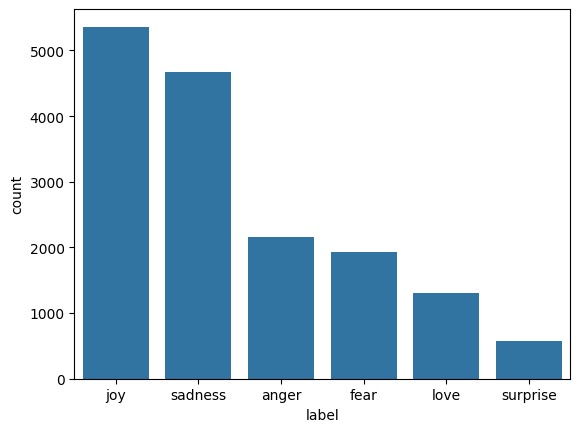

In [57]:
sns.countplot(x='label',data=df_train,order=df_train['label'].value_counts().index)
plt.show()

In [58]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


# **4. Data Preprocessing - Using NLP**

Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [59]:
# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

import numpy as np
from sklearn.model_selection import train_test_split

# Convert labels to NumPy arrays
train_label = np.array(train_label)
test_label = np.array(test_label)

# ------------------------------------------------------------
# Keep the TEST set completely separate
# ------------------------------------------------------------
# Split ONLY the training data into:
# 90% Training
# 10% Validation

X_train, X_val, y_train, y_val = train_test_split(
    padded_train_sequence,
    train_label,
    test_size=0.10,
    random_state=42,
    stratify=train_label
)

# ------------------------------------------------------------
# Display dataset sizes
# ------------------------------------------------------------

print("Dataset Split")
print("-" * 40)
print(f"Training samples   : {len(X_train)}")
print(f"Validation samples : {len(X_val)}")
print(f"Test samples       : {len(padded_test_sequence)}")

print("\nShapes")
print("-" * 40)
print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"y_val   : {y_val.shape}")
print(f"X_test  : {padded_test_sequence.shape}")
print(f"y_test  : {test_label.shape}")

# ------------------------------------------------------------
# Verify class distribution
# ------------------------------------------------------------

print("\nTraining class distribution:")
print(np.bincount(y_train))

print("\nValidation class distribution:")
print(np.bincount(y_val))

print("\nTest class distribution:")
print(np.bincount(test_label))

Dataset Split
----------------------------------------
Training samples   : 14400
Validation samples : 1600
Test samples       : 2000

Shapes
----------------------------------------
X_train : (14400, 50)
y_train : (14400,)
X_val   : (1600, 50)
y_val   : (1600,)
X_test  : (2000, 50)
y_test  : (2000,)

Training class distribution:
[4199 4826 1174 1943 1743  515]

Validation class distribution:
[467 536 130 216 194  57]

Test class distribution:
[581 695 159 275 224  66]


In [60]:
padded_train_sequence= pad_sequences(train_sequence,maxlen=50,padding='post',truncating='post')
padded_test_sequence= pad_sequences(test_sequence,maxlen=50,padding='post',truncating='post')


padded_train_sequence

array([[   2,  139,    3, ...,    0,    0,    0],
       [   2,   40,  101, ...,    0,    0,    0],
       [  17, 3060,    7, ...,    0,    0,    0],
       ...,
       [   2,    3,  327, ...,    0,    0,    0],
       [   2,    3,   14, ...,    0,    0,    0],
       [   2,   47,    7, ...,    0,    0,    0]], dtype=int32)

In [61]:
train_label = np.array(train_label)
test_label = np.array(test_label)

In [62]:
train_label

array([0, 0, 3, ..., 1, 3, 0])

In [63]:
test_label

array([0, 0, 0, ..., 1, 1, 4])

In [64]:
num_classes = len(np.unique(train_label))
num_classes

6

# **5. Shared Training Utilities**

Compute balanced class weights to handle dataset skew and setup early stopping.

In [82]:
# ==========================================
# TRAIN / VALIDATION SPLIT
# ==========================================

X = np.array(train_text)
y = np.array(train_label)

# Split ONLY the original training data
# 90% Training
# 10% Validation

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=SEED,
    stratify=y
)

# Keep original test set completely untouched
X_test = np.array(test_text)
y_test = np.array(test_label)

print("Dataset Split")
print("-" * 40)

print(f"Training samples   : {len(X_train)}")
print(f"Validation samples : {len(X_val)}")
print(f"Test samples       : {len(X_test)}")

print("\nShapes")
print("-" * 40)

print(f"X_train : {X_train.shape}")
print(f"y_train : {y_train.shape}")

print(f"X_val   : {X_val.shape}")
print(f"y_val   : {y_val.shape}")

print(f"X_test  : {X_test.shape}")
print(f"y_test  : {y_test.shape}")

print("\nTraining class distribution:")
print(np.bincount(y_train))

print("\nValidation class distribution:")
print(np.bincount(y_val))

print("\nTest class distribution:")
print(np.bincount(y_test))

Dataset Split
----------------------------------------
Training samples   : 14400
Validation samples : 1600
Test samples       : 2000

Shapes
----------------------------------------
X_train : (14400,)
y_train : (14400,)
X_val   : (1600,)
y_val   : (1600,)
X_test  : (2000,)
y_test  : (2000,)

Training class distribution:
[4199 4826 1174 1943 1743  515]

Validation class distribution:
[467 536 130 216 194  57]

Test class distribution:
[581 695 159 275 224  66]


In [66]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight ='balanced',
    classes      = np.unique(train_label),
    y = train_label
)
class_weight_dict=dict(enumerate(class_weights))


In [67]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights = True
)


# **6. Phase 1 — Plain Foundational Models**

Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

# **6.1 Model 1 — Simple RNN**

Plain unrolled Recurrent Neural Network.

In [68]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

# Defining variables locally to ensure the cell runs independently
max_words = 10000
num_classes = 6

rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128,input_length=50),
    # Added return_sequences=True to allow stacking
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') # OUTPUT LAYER
])

rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [69]:
rnn_model.fit(
    padded_train_sequence,
    train_label,
    validation_data=(padded_test_sequence, test_label),
    epochs=20,
    batch_size=32,

    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

# Corrected 'test_labels' to 'test_label' and fixed the case sensitivity in the print statement
rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_label)
print(f"RNN loss : {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.1619 - loss: 1.9224 - val_accuracy: 0.2210 - val_loss: 1.7661
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1549 - loss: 1.8158 - val_accuracy: 0.1405 - val_loss: 1.8944
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1443 - loss: 1.8692 - val_accuracy: 0.3290 - val_loss: 1.7510
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1379 - loss: 1.8165 - val_accuracy: 0.0875 - val_loss: 1.7809
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1427 - loss: 1.8054 - val_accuracy: 0.0875 - val_loss: 1.7922
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1457 - loss: 1.8035 - val_accuracy: 0.0875 - val_loss: 1.7870
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3290 - loss: 1.7510
RNN loss : 1.7510316371917725
RNN Accuracy: 0.32899999618530273



# **6.2 Model 2 — Standard LSTM**

Plain stacked Long Short-Term Memory network.

In [70]:
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128,input_length=50),
    # Added return_sequences=True to allow stacking
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') # OUTPUT LAYER
])
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


lstm_model.fit(
    padded_train_sequence,
    train_label,
    validation_data=(padded_test_sequence, test_label),
    epochs=20,
    batch_size=32,

    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

# Corrected 'test_labels' to 'test_label' and fixed the case sensitivity in the print statement
lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_label)
print(f"LSTM loss : {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.1846 - loss: 1.7947 - val_accuracy: 0.3470 - val_loss: 1.7798
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.1748 - loss: 1.7939 - val_accuracy: 0.3445 - val_loss: 1.7759
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.2016 - loss: 1.7927 - val_accuracy: 0.2815 - val_loss: 1.7792
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3470 - loss: 1.7798
LSTM loss : 1.7798473834991455
LSTM Accuracy: 0.34700000286102295


# **6.3 Model 3 — Standard GRU**

Plain stacked Gated Recurrent Unit network.


# **6.4 Phase 1 Ranking & Selection**

In [71]:
gru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128,input_length=50),
    # Added return_sequences=True to allow stacking
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') # OUTPUT LAYER
])
gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


gru_model.fit(
    padded_train_sequence,
    train_label,
    validation_data=(padded_test_sequence, test_label),
    epochs=20,
    batch_size=32,

    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

# Corrected 'test_labels' to 'test_label' and fixed the case sensitivity in the print statement
gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_label)
print(f"GRU loss : {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.1621 - loss: 1.7949 - val_accuracy: 0.2885 - val_loss: 1.7833
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1645 - loss: 1.7939 - val_accuracy: 0.0480 - val_loss: 1.7914
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1882 - loss: 1.7794 - val_accuracy: 0.1920 - val_loss: 1.7948
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2885 - loss: 1.7833
GRU loss : 1.7832533121109009
GRU Accuracy: 0.28850001096725464


Rank foundational models to pick the best base cell for Phase 2.

In [72]:
result_df= pd.DataFrame({
    'Model': ['RNN','LSTM','GRU'],
    'Test Loss': [rnn_loss,lstm_loss,gru_loss],
    'Test Accuracy' :[rnn_accuracy,lstm_accuracy,gru_accuracy]
}).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
1,LSTM,1.779847,0.3470
0,RNN,1.751032,0.3290
2,GRU,1.783253,0.2885



## **7. Phase 2 — Advanced Bidirectional GRU**

Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

# 7.1 Model 4 — Advanced Stacked Bidirectional GRU

In [73]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, Embedding, GRU, Dropout, Dense

# Defining parameters locally to ensure the cell runs independently


BiGRU = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') # output layer
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Train & Evaluate Advanced Bidirectional GRU

In [74]:
BiGRU.fit(
    padded_train_sequence,
    train_label,
    validation_data=(padded_test_sequence, test_label),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.5760 - loss: 1.0328 - val_accuracy: 0.8885 - val_loss: 0.3755
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9142 - loss: 0.2425 - val_accuracy: 0.9065 - val_loss: 0.2868
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9446 - loss: 0.1558 - val_accuracy: 0.9040 - val_loss: 0.3160
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9598 - loss: 0.1079 - val_accuracy: 0.9105 - val_loss: 0.3420
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9724 - loss: 0.0846 - val_accuracy: 0.9050 - val_loss: 0.3766


In [75]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_label)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9065 - loss: 0.2868
BiGRU Loss: 0.28683099150657654
BiGRU Accuracy: 0.906499981880188


## **8. Overall Evaluation & Bias Analysis**

Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.




# 8.1 Final Model Confusion Matrices (Raw Counts & Normalized %)

In [76]:
#let suppose the sadness = 5%, joy=14%, anger=67%,love=9%, surprise=50%,fear=2% this were the the value return , so to give out the results which emotions is
#best suited for the sentence that why argmax is used is used to deterime which value is getting highest percentage will be printed

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


<Axes: >

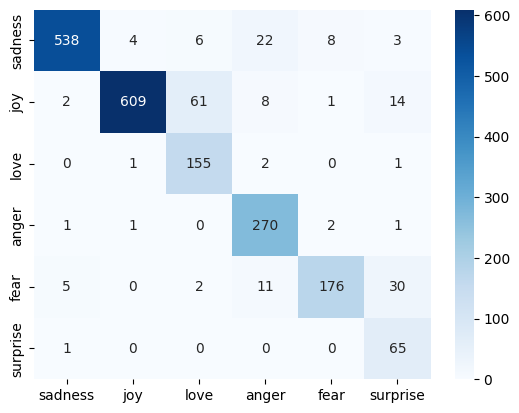

In [79]:
from sklearn.metrics import confusion_matrix
import numpy as np
BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)


# **9. Final Predictions**

Test the winning model on unseen sample sentences.

In [80]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

# Convert to sequences and pad using the restored function
sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

# Get model predictions
predictions = BiGRU.predict(sample_padded_sequences)
sample_predictions = np.argmax(predictions, axis=1)

# Print results
for i in range(len(sample_texts)):
    print(f"Text: {sample_texts[i]}")
    print(f"Predicted Emotion: {label_names[sample_predictions[i]]}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise

Text: I feel so alone and hopeless today.
Predicted Emotion: sadness

Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger

Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear

Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise

